# JobMatch AI — Notebook 03: Embeddings e Similaridade Semântica

**Projeto:** JobMatch AI — Sistema de Matching Currículo-Vaga com NLP/Deep Learning
**Autor:** Eduardo Matos
**Etapa:** Geração de embeddings e análise de similaridade semântica (N=162)

## Por que embeddings, e não só tokenização

A tokenização (Notebook 02) quebra o texto em subwords, mas não gera, por si só,
um único vetor que resuma o *significado* de uma vaga inteira — para isso, usamos
uma camada adicional: modelos de **sentence embeddings**, construídos especificamente
para que frases com significado parecido gerem vetores matematicamente próximos.

## Objetivo deste notebook

1. Gerar um embedding (vetor numérico) para cada uma das 162 vagas
2. Calcular similaridade de cosseno entre elas, para verificar se vagas
   semanticamente parecidas ficam "próximas" no espaço vetorial
3. Visualizar essa estrutura via redução de dimensionalidade (PCA)
4. Usar esses resultados como validação indireta do dataset antes do fine-tuning,
   e como possível baseline de recomendação por similaridade

In [9]:
!pip install sentence-transformers -q

In [10]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

CAMINHO_CSV = '/content/drive/MyDrive/jobmatch-ai/data/vagas_clean_v2.csv'
df = pd.read_csv(CAMINHO_CSV)

print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (162, 13)


,id,fonte,titulo,empresa,descricao,requisitos,senioridade,area,remoto,fit_percentual,url,data_coleta,origem_coleta
0,1,LinkedIn,Fraud Data Analyst - Pleno,Cora,"Das 21 milhões de empresas do Brasil, 93% são ...",Fluência em SQL e autonomia no uso de Python o...,pleno,Ciencia de Dados,sim,75,https://www.linkedin.com/jobs/collections/reco...,07/07/2026,Manual
1,2,LinkedIn,Data science,hire fide,"We are hiring for one of our clients, seeking ...","• Proficiency in Python, including libraries s...",junior,Ciencia de Dados,sim,60,https://www.linkedin.com/jobs/search/?alertAct...,05/07/2026,Manual
2,3,LinkedIn,Pessoa Cientista de Dados - Vaga afirmativa pa...,Artefact,Nós da Artefact LatAm acreditamos e vivemos um...,Ter cursado um curso de graduação em ciência d...,junior,Ciencia de Dados,sim,80,https://www.linkedin.com/jobs/collections/reco...,04/07/2026,Manual
3,4,LinkedIn,Cientista de Dados - Trabalho Remoto,BairesDev,"Há mais de 15 anos, a BairesDev® é líder em pr...",- 3+ anos de experiência na aplicação de técni...,junior,Ciencia de Dados,sim,60,https://www.linkedin.com/jobs/collections/reco...,05/07/2026,Manual
4,5,LinkedIn,ciencia de dados pricing,pricing,A RD Saúde é uma empresa líder no mercado bras...,• Ensino superior completo ou em andamento nas...,junior,Ciencia de Dados,sim,75,https://rdsaude-corporativo.gupy.io/jobs/11578256,05/07/2026,Manual


## 1. Carregando o modelo de embeddings

Usamos `paraphrase-multilingual-MiniLM-L12-v2`, um modelo multilíngue da
biblioteca `sentence-transformers`, com bom desempenho em português e
otimizado especificamente para tarefas de similaridade semântica — diferente
do BERTimbau "cru" usado no notebook anterior, que não foi originalmente
ajustado para gerar um único vetor representativo de frase inteira.


In [11]:
from sentence_transformers import SentenceTransformer

# Modelo multilíngue, com bom suporte a português, otimizado para similaridade semântica
NOME_MODELO_EMBEDDING = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

modelo_embedding = SentenceTransformer(NOME_MODELO_EMBEDDING)

print('Modelo carregado com sucesso!')
print('Dimensão do embedding gerado:', modelo_embedding.get_sentence_embedding_dimension())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo carregado com sucesso!
Dimensão do embedding gerado: 384


/tmp/ipykernel_1252/410997265.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('Dimensão do embedding gerado:', modelo_embedding.get_sentence_embedding_dimension())


## 2. Gerando os embeddings das 162 vagas

Convertemos cada descrição de vaga em um vetor de 384 números, usando o modelo
carregado. Essa é a "tradução matemática" do texto — o significado passa a
existir como posição num espaço vetorial, não mais como palavras.


In [12]:
# Gerando um embedding (vetor de 384 números) para cada descrição de vaga
embeddings = modelo_embedding.encode(df['descricao'].tolist(), show_progress_bar=True)

print("Formato da matriz de embeddings:", embeddings.shape)
print("\nExemplo - primeiros 10 números do embedding da vaga 0:")
print(embeddings[0][:10])

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Formato da matriz de embeddings: (162, 384)

Exemplo - primeiros 10 números do embedding da vaga 0:
[ 0.03174086 -0.09495567 -0.07452926  0.00495416  0.28672758  0.00468636
 -0.06876093  0.04558412  0.18157513  0.14829548]


**Interpretação:** o resultado esperado é uma dimensão de 384 — ou seja, cada
vaga (independente do tamanho do texto original) será representada por um
vetor de 384 números decimais nesse espaço semântico.


In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

matriz_similaridade = cosine_similarity(embeddings)
print("Formato da matriz de similaridade:", matriz_similaridade.shape)

# Amostra: 3 vagas de cada faixa de fit, escolhidas aleatoriamente
np.random.seed(42)
indices_alto = df[df['fit_percentual'] >= 60].sample(3).index
indices_medio = df[(df['fit_percentual'] >= 30) & (df['fit_percentual'] < 60)].sample(3).index
indices_baixo = df[df['fit_percentual'] < 30].sample(3).index
amostra_indices = list(indices_alto) + list(indices_medio) + list(indices_baixo)

for i in amostra_indices:
    similaridades = matriz_similaridade[i].copy()
    similaridades[i] = -1
    idx_mais_parecida = np.argmax(similaridades)

    print(f"\n'{df.iloc[i]['titulo'][:40]}' (fit={df.iloc[i]['fit_percentual']})")
    print(f"  → mais parecida com: '{df.iloc[idx_mais_parecida]['titulo'][:40]}' "
          f"(fit={df.iloc[idx_mais_parecida]['fit_percentual']}, "
          f"similaridade={similaridades[idx_mais_parecida]:.3f})")

Formato da matriz de similaridade: (162, 162)

'Fraud Data Analyst - Pleno' (fit=75)
  → mais parecida com: 'Analista Cientista de Dados Júnior - Afi' (fit=80, similaridade=0.773)

'analista de dados' (fit=80)
  → mais parecida com: 'Cientista de Dados Junior' (fit=80, similaridade=0.746)

'Data Science Specialist' (fit=75)
  → mais parecida com: 'Data Science Intern' (fit=35, similaridade=0.741)

'Senior Data Science' (fit=40)
  → mais parecida com: 'Engenheiro(a) de Dados' (fit=60, similaridade=0.739)

'Cientista de Dados Sênior | Remoto' (fit=45)
  → mais parecida com: 'Cientista de Dados' (fit=45, similaridade=0.695)

'Analista De Bi Júnior' (fit=45)
  → mais parecida com: 'Analista de BI Júnior' (fit=45, similaridade=0.791)

'ANALISTA SUPORTE TI - JR' (fit=15)
  → mais parecida com: 'Analista Suporte Ti - Jr - Lojas' (fit=15, similaridade=1.000)

'Assistente financeiro' (fit=10)
  → mais parecida com: 'Assistente Financeiro - Assistente Finan' (fit=10, similaridade=0.767)

'Telema

**Interpretação da amostra de similaridade:**

- Vagas quase idênticas (mesma empresa, cidades diferentes) atingem similaridade
  próxima de 1.0, como esperado
- Vagas de mesma categoria e fit similar tendem a se agrupar corretamente
  (ex: Analista de BI Júnior ↔ Analista de BI Júnior, similaridade 0.79)
- Vagas de baixo fit (Telemarketing, Assistente Financeiro) se identificam
  corretamente entre si, confirmando separação de domínio
- **Limitação identificada:** "Data Science Specialist" (fit=75) ficou mais
  similar a "Data Science Intern" (fit=35) do que a outras vagas de fit alto —
  o embedding genérico captura bem a sobreposição lexical de área técnica, mas
  não pondera adequadamente a diferença de senioridade dentro da mesma área.
  Essa é uma limitação conhecida de embeddings pré-treinados não supervisionados,
  que reforça a necessidade do fine-tuning supervisionado (próximo notebook).

## 4. Visualização: mapa semântico via PCA

Como o espaço de 384 dimensões não pode ser visualizado diretamente, usamos
PCA (Análise de Componentes Principais) para reduzir a 2 dimensões, preservando
ao máximo as distâncias relativas entre os pontos. Com N=162, essa é a forma
correta de visualizar a estrutura do dataset — diferente do heatmap par a par,
que se tornaria ilegível nessa escala (162×162 = mais de 26 mil células).

Variância explicada pelos 2 componentes: 0.217


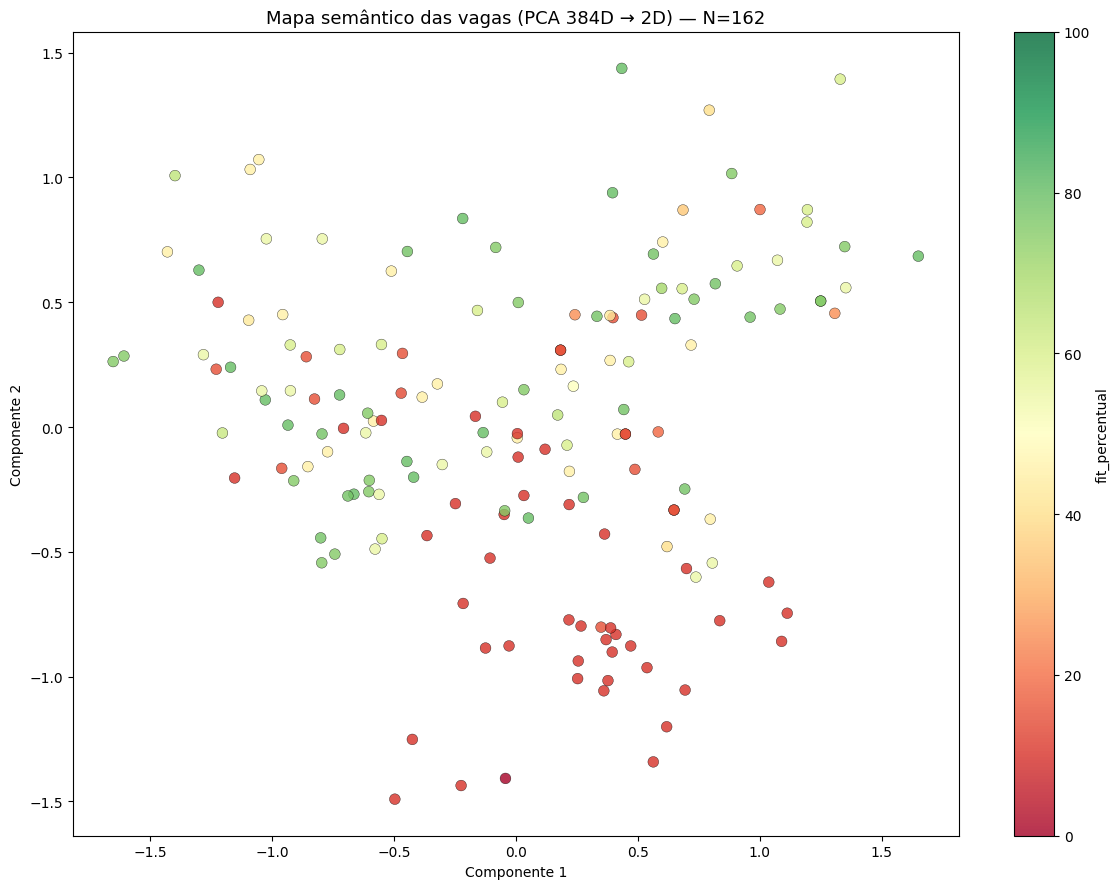

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

print("Variância explicada pelos 2 componentes:", pca.explained_variance_ratio_.sum().round(3))

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=df['fit_percentual'], cmap='RdYlGn', s=60,
                      edgecolors='black', linewidth=0.3, alpha=0.8, vmin=0, vmax=100)

plt.colorbar(scatter, label='fit_percentual')
ax.set_title('Mapa semântico das vagas (PCA 384D → 2D) — N=162', fontsize=13)
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/jobmatch-ai/notebooks/mapa_semantico_pca_v2.png', dpi=120)
plt.show()

## 5. Explorando visualização não-linear (UMAP)

Com N=162, o volume de dados agora é suficiente para usar técnicas de redução
de dimensionalidade não-lineares, que podem capturar estruturas mais complexas
que o PCA (linear) não representa bem — especialmente relevante já que o PCA
explicou apenas 21.7% da variância total.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


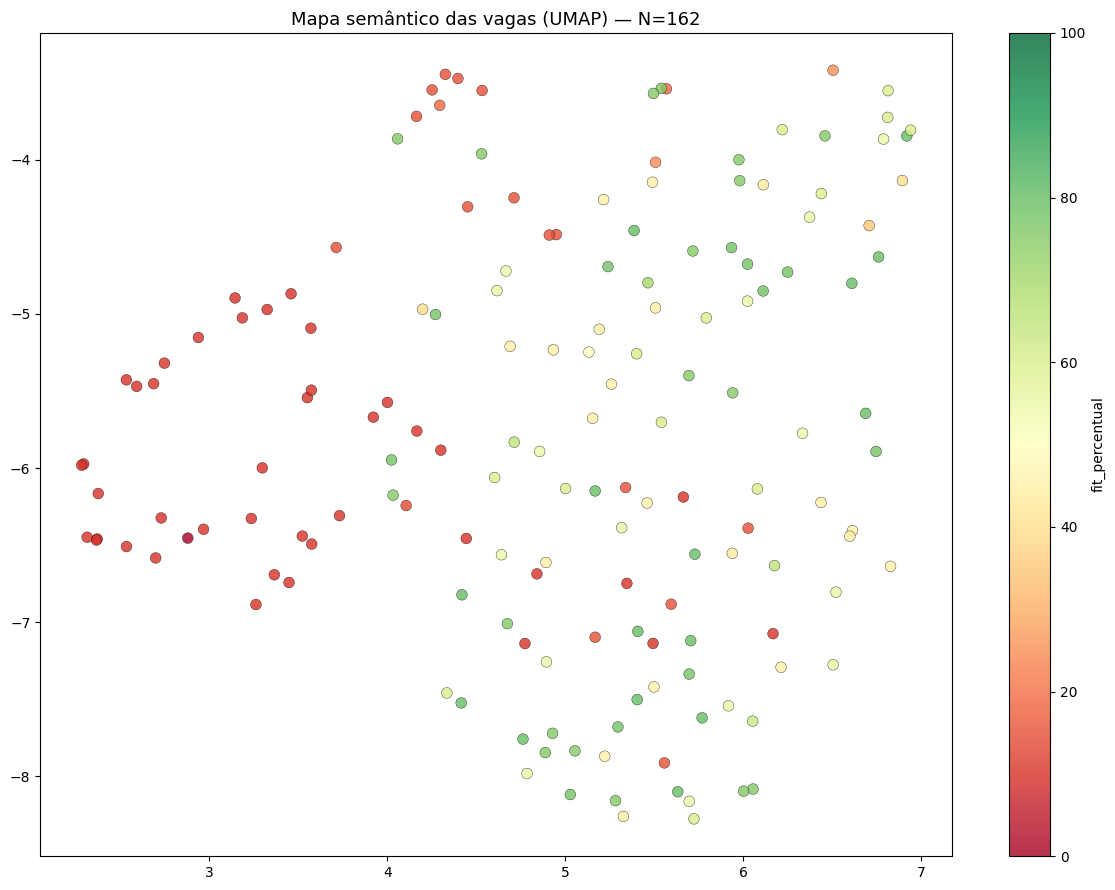

In [18]:
!pip install umap-learn -q

import umap

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_umap = reducer.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(embeddings_umap[:, 0], embeddings_umap[:, 1],
                      c=df['fit_percentual'], cmap='RdYlGn', s=60,
                      edgecolors='black', linewidth=0.3, alpha=0.8, vmin=0, vmax=100)
plt.colorbar(scatter, label='fit_percentual')
ax.set_title('Mapa semântico das vagas (UMAP) — N=162', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/jobmatch-ai/notebooks/mapa_semantico_umap.png', dpi=120)
plt.show()

**Comparação PCA vs UMAP:** o UMAP mostrou separação visual bem mais nítida
que o PCA, especialmente para o cluster de vagas fora de área (fit baixo),
que aparece claramente isolado. Isso é esperado tecnicamente: UMAP preserva
relações de vizinhança local, enquanto PCA preserva variância global — com
dados de alta dimensionalidade (384D) e estrutura não-linear, técnicas como
UMAP tendem a representar melhor os agrupamentos reais.

Ainda assim, observa-se sobreposição entre vagas de fit médio e alto, refletindo
a natureza mais sutil dessa fronteira em comparação com "área técnica vs.
não-técnica" — reforçando a necessidade de um modelo supervisionado (fine-tuning)
para capturar essa nuance mais fina.

## Conclusões — Embeddings e Similaridade Semântica (N=162)

- Modelo: paraphrase-multilingual-MiniLM-L12-v2, embeddings de 384 dimensões
- PCA explicou apenas 21.7% da variância (2 componentes) — esperado dado o
  aumento de complexidade/diversidade do dataset em relação à versão N=15
- UMAP mostrou separação visual mais nítida que PCA, confirmando estrutura
  semântica real, especialmente para vagas fora de área
- Limitação recorrente: embeddings genéricos confundem vagas com forte
  sobreposição lexical de título/área mas senioridade diferente (ex:
  "Specialist" vs "Intern")
- Conclusão geral: o dataset de 162 vagas tem sinal semântico suficiente para
  justificar o próximo passo — fine-tuning supervisionado do BERTimbau

- Próximo passo: Notebook 04 — Fine-tuning do BERTimbau